# Recommender Systems
***by P. Bekirakis***



In this lecture we will introduce and perform a quick Exploratory Data Analysis on [MovieLens](https://grouplens.org/datasets/movielens/) dataset that we will use for our project on Recommender Systems. We will also discuss briefly about the cold start problem and the solution of offering the most popular item.



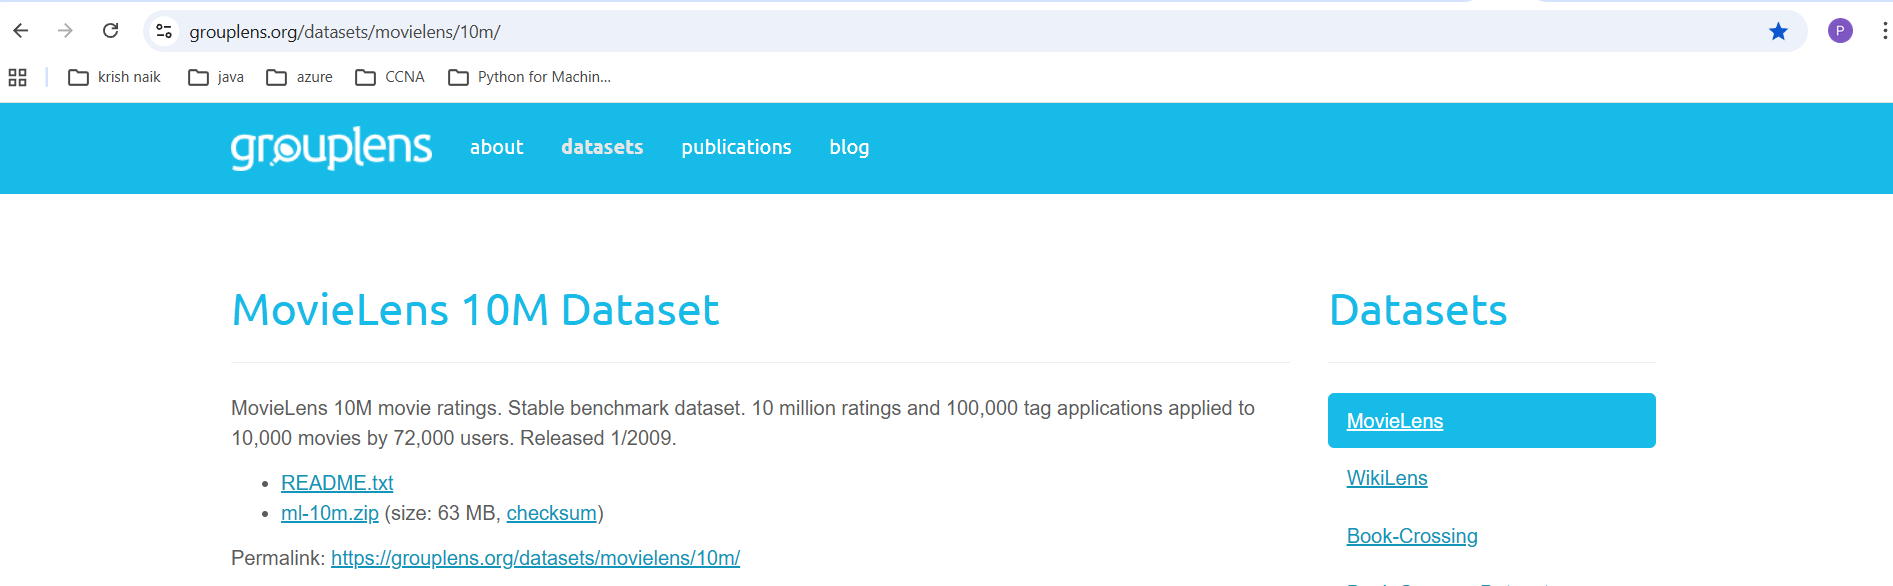

## Python packages

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from scipy.sparse import coo_matrix
import scipy.sparse as sparse
from sklearn.metrics import mean_squared_error
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_distances

1A. Φορτώστε από το ml-10m dataset τα αρχεία movies.dat και ratings.dat σε δύο dataframes.



In [3]:
ratings_list = [i.strip().split("::") for i in open('ratings.dat', 'r').readlines()]
ratings_df = pd.DataFrame(ratings_list, columns = ['UserID', 'MovieID', 'Rating', 'Timestamp']).astype(float)
ratings_df.head()

,UserID,MovieID,Rating,Timestamp
0,1.0,122.0,5.0,838985046.0
1,1.0,185.0,5.0,838983525.0
2,1.0,231.0,5.0,838983392.0
3,1.0,292.0,5.0,838983421.0
4,1.0,316.0,5.0,838983392.0


In [4]:
#We uploaded 10.000.054 lines and 4 columns

print(f'ratings_df dataframe shape {ratings_df.shape}')
print(f'Unique number of users in ratings {ratings_df['UserID'].nunique()}')
print(f'Unique number of movies in ratings {ratings_df['MovieID'].nunique()}')

#anaferei 10.677 tainies pou einai unique ws pros ta rating tous. I askisi anaferei 10.681. kai 69.878 users pou einai unique

ratings_df dataframe shape (10000054, 4)
Unique number of users in ratings 69878
Unique number of movies in ratings 10677


In [7]:
movies_list = [i.strip().split("::") for i in open('movies.dat', 'r',encoding='utf-8').readlines()]
movies_df = pd.DataFrame(movies_list, columns = ['MovieID', 'Title', 'Genres'])
movies_df['MovieID'] = movies_df['MovieID'].apply(pd.to_numeric)
movies_df.head()

,MovieID,Title,Genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [8]:
#We uploaded 10.681 lines and 3 columns

print(f'movies_df dataframe shape {movies_df.shape}')
print(f'Unique number of movies {movies_df['MovieID'].nunique()}')

#anaferei 10.681 tainies pou einai unique. Den exw vathmologies gia oles epeidi panw mas edine 10.677. Ara oi 4 den exoun vathmologies??

movies_df dataframe shape (10681, 3)
Unique number of movies 10681


1B. Ενώστε τα δύο dataframes και δημιουργήστε μια στήλη με το όνομα "year" που περιέχει το έτος που δόθηκε κάθε βαθμολογία.

In [9]:
#Έχουμε 2 dataframes. To movies.dat και ratings.dat. Επειδή και τα 2 έχουν κοινή στήλη την MovieID θα κάνω merge ως προς αυτήν.

movies_rating_df = pd.merge(movies_df, ratings_df, on='MovieID')

In [10]:
#Στην ένωση αυτών φτιάχνω μία στήλη με το όνομα "year" για το έτος που δώθηκε η κάθε βαθμολογία

# Define the base date  -->  Μετατροπή από Timestamp σε πλήρη ημερομηνία

base_date = datetime(1970, 1, 1)

movies_rating_df['Year'] = movies_rating_df['Timestamp'].apply(lambda x: base_date + timedelta(seconds=x))
movies_rating_df.head()

,MovieID,Title,Genres,UserID,Rating,Timestamp,Year
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5.0,1.0,8.579113e+08,1997-03-09 12:41:04
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,14.0,3.0,1.133572e+09,2005-12-03 01:06:47
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,18.0,3.0,1.111546e+09,2005-03-23 02:45:31
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,23.0,5.0,8.495435e+08,1996-12-02 16:18:02
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,24.0,5.0,8.682542e+08,1997-07-07 05:43:57


In [11]:
# Basic Statistics

print(f"Total ratings: {len(movies_rating_df):,}")
print(f"Unique users:  {movies_rating_df['UserID'].nunique():,}")
print(f"Unique movies: {movies_rating_df['MovieID'].nunique():,}")
print(f"Rating scale:  {movies_rating_df['Rating'].min()} – {movies_rating_df['Rating'].max()}")
print(f"Mean rating:   {movies_rating_df['Rating'].mean():.2f}")
print(f"\nTop 3 most common ratings:")
print(movies_rating_df['Rating'].value_counts().head(3))

Total ratings: 10,000,054
Unique users:  69,878
Unique movies: 10,677
Rating scale:  0.5 – 5.0
Mean rating:   3.51

Top 3 most common ratings:
Rating
4.0    2875850
3.0    2356676
5.0    1544812
Name: count, dtype: int64


In [ ]:
# Η πιο συχνή βαθμολογία είναι 4.0 με 28.76%

print(f"\nRating distribution (%):")
print((movies_rating_df['Rating'].value_counts(normalize=True).sort_index() * 100).round(2))


Rating distribution (%):
Rating
0.5     0.95
1.0     3.84
1.5     1.18
2.0     7.90
2.5     3.70
3.0    23.57
3.5     8.80
4.0    28.76
4.5     5.85
5.0    15.45
Name: proportion, dtype: float64


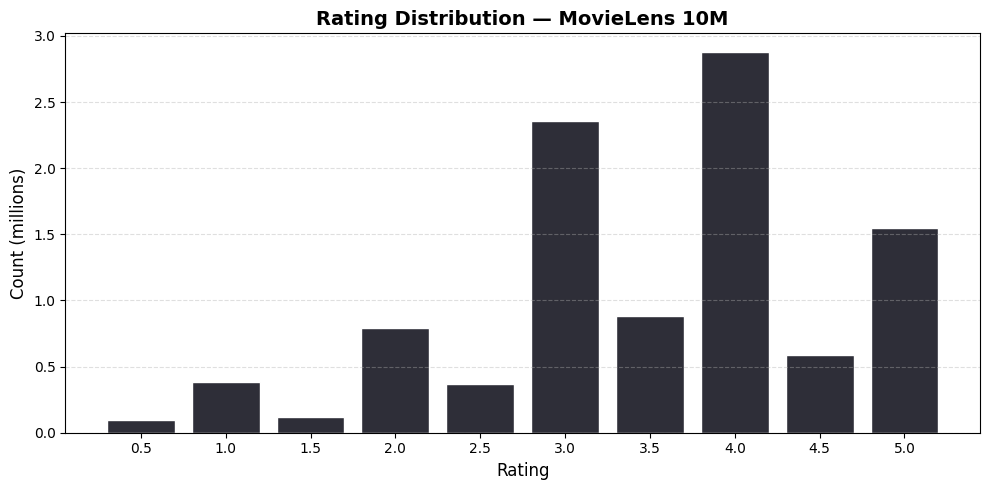

Rating scale: 0.5 – 5.0
Mean rating:  3.51
Most common:  4.0 stars


In [13]:
# Rating Distribution Chart

import matplotlib.pyplot as plt

rating_counts = movies_rating_df['Rating'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(rating_counts.index, rating_counts.values / 1_000_000, color='#2E2E38', edgecolor='white', width=0.4)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Count (millions)', fontsize=12)
plt.title('Rating Distribution — MovieLens 10M', fontsize=14, fontweight='bold')
plt.xticks(rating_counts.index)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f"Rating scale: {movies_rating_df['Rating'].min()} – {movies_rating_df['Rating'].max()}")
print(f"Mean rating:  {movies_rating_df['Rating'].mean():.2f}")
print(f"Most common:  {movies_rating_df['Rating'].value_counts().index[0]} stars")

In [14]:
# Για να εμφανιζεται μόνο το έτος της αξιολόγησης που δόθηκε

movies_rating_df['Year'] = movies_rating_df['Timestamp'].apply(lambda x: (base_date + timedelta(seconds=x)).year)
movies_rating_df.head()

,MovieID,Title,Genres,UserID,Rating,Timestamp,Year
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5.0,1.0,8.579113e+08,1997
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,14.0,3.0,1.133572e+09,2005
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,18.0,3.0,1.111546e+09,2005
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,23.0,5.0,8.495435e+08,1996
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,24.0,5.0,8.682542e+08,1997


2. Βρείτε τα 5 κορυφαία είδη (genres) που είχαν τη μεγαλύτερη μείωση στη μέση ετήσια βαθμολογία από το πρώτο έτος που υπάρχουν δεδομένα μέχρι το τελευταίο. Σημειώστε ότι το ελάχιστο έτος που έχουμε αξιολογήσεις μπορεί να διαφέρει για κάθε είδος.

In [15]:
# Πχ μπορεί μία ταινία να έχει Adventure|Animation|Children|Comedy|Fantasy αρκετά είδη (genres) στην περιγραφή της

# Σπάω τα διαφορετικά είδη σε ξεχωριστές γραμμές

movies_rating_df['Genres'] = movies_rating_df['Genres'].str.split('|')
genres_df = movies_rating_df.explode('Genres')

genres_df.head()


,MovieID,Title,Genres,UserID,Rating,Timestamp,Year
0,1,Toy Story (1995),Adventure,5.0,1.0,857911264.0,1997
0,1,Toy Story (1995),Animation,5.0,1.0,857911264.0,1997
0,1,Toy Story (1995),Children,5.0,1.0,857911264.0,1997
0,1,Toy Story (1995),Comedy,5.0,1.0,857911264.0,1997
0,1,Toy Story (1995),Fantasy,5.0,1.0,857911264.0,1997


In [16]:
# Βρίσκω την μέση ετήσια βαθμολογία ανά είδος

# Ομαδοποιώ τα data κατά έιδος και Χρονολογία μαζί πχ. (Animation, 1997), (Animation, 1998) 
# Από αυτές τις ομάδες παίρνω μόνο τη στήλη με τις βαθμολογίες[Rating] και υπολογίζω την μέση βαθμολογία
# πχ Animation, 1997 ---> Βρίσκω τον Μ.Ο της βαθμολογίας όλων των ταινιών Κωμωδίας για το 1997


genre_year_rating = genres_df.groupby(['Genres', 'Year'])['Rating'].mean()

genre_year_rating.head()

Genres              Year
(no genres listed)  2004    2.750000
                    2007    4.000000
                    2008    4.000000
Action              1995    3.000000
                    1996    3.440509
Name: Rating, dtype: float64

In [17]:
# Με το reset_index() φαίρνω σε σωστή μορφή τις ομάδες. Με το groupby χάνεται η αρίθμηση
# Αντί για γραμμή 0 θα έχω πχ "no genres listed, 2004" ως αρίθμηση (labels = 0, 1, 2, Κλπ).
# Με το reset_index() επαναφέρω την αρίθμηση σωστά

# Μαζί με τη Μέση Βαθμολογία παίρνω και τον συνολικό αριθμό αξιολογήσεων

genre_year_rating = genres_df.groupby(['Genres', 'Year'])['Rating'].agg(['mean', 'count']).reset_index()
genre_year_rating.columns = ['Genres', 'Year', 'Rating', 'Count_Ratings']
genre_year_rating.head()

,Genres,Year,Rating,Count_Ratings
0,(no genres listed),2004,2.750000,2
1,(no genres listed),2007,4.000000,3
2,(no genres listed),2008,4.000000,2
3,Action,1995,3.000000,1
4,Action,1996,3.440509,331387


In [18]:
# Βρήκα τον Μ.Ο της βαθμολογίας για το κάθε είδος για κάθε έτος.
# Βρίσκω τώρα το Μ.Ο της βαθμολογίας για το πρώτο και το τελευταίο έτος ανά είδος ταινίας

# Κάνω Groupby μόνο ως προς το είδος της ταινίας. Κάθε group έχει όλες τις χρονιές για το κάθε είδος
# πχ Action → 1995, 1996, 1997, 1998
# Από το κάθε group παίρνω την πρώτη γραμμή που είναι και η πρώτη χρονιά αξιολογήσεων
# πχ Action → 1995 (Μ.Ο βαθμολογίας των ταινιών Action για το έτος 1995 που είναι το πρώτο έτος αξιολόγησης)

# Αντίστοιχα ισχύει το ίδιο για την τελευταία χρονιά

# [['Genres', 'Rating']] Κρατάω μόνο το Είδος της ταινίας και την Αξιολόγηση που έχει για την πρώτη και αντίστοιχα για την τελευταία χρονιά αξιολογήσεων

# Προσθέτω και τον αριθμό των αξιολογήσεων για την πρώτη και αντίστοιχα για την τελευταία χρονιά αξιολογήσεων

first_year = genre_year_rating.groupby('Genres').first().reset_index()[['Genres', 'Rating', 'Count_Ratings']].rename(columns={'Rating': 'first_rating', 'Count_Ratings': 'first_count'})
last_year = genre_year_rating.groupby('Genres').last().reset_index()[['Genres', 'Rating', 'Count_Ratings']].rename(columns={'Rating': 'last_rating', 'Count_Ratings': 'last_count'})


In [19]:
# Κάνω merge την first_year και την last_year ως προς την στήλη Genres και υπολογίζω την μείωση στην Μέση Ετήσια Βαθμολογία

genre_change_rating = pd.merge(first_year, last_year, on='Genres')
genre_change_rating['decrease'] = genre_change_rating['first_rating'] - genre_change_rating['last_rating']


In [20]:
# Βρίσκω τα 5 κορυφαία είδη (genres) που είχαν τη μεγαλύτερη μείωση στη Μέση Ετήσια Βαθμολογία

# sort_values() — sorts by the data inside a column --> Αυτό που θέλω

# sort_index() — sorts by the row counters (index) --> Σορτάρει απλά την αρίθμηση, τα labels δηλαδή

# Τα Top5 είδη ταινιών με τη μεγαλύτερη πτώση στην Μέση Ετήσια Βαθμολογία είναι τα κάτωθι:

top5 = genre_change_rating.sort_values('decrease', ascending=False).head(5)
top5


,Genres,first_rating,first_count,last_rating,last_count,decrease
11,Horror,5.000000,1,3.310458,1224,1.689542
17,Thriller,5.000000,1,3.472470,3814,1.527530
14,Mystery,5.000000,1,3.659091,990,1.340909
6,Crime,4.000000,2,3.619338,2296,0.380662
18,War,3.943008,59973,3.723529,765,0.219478


3. Επηρεάζεται η προηγούμενη ανάλυση σχετικά με τη μείωση της δημοτικότητας του 
είδους από τον αριθμό των αξιολογήσεων; Θα το λαμβάνατε αυτό υπόψη; Κάντε μια προσαρμογή για 
αυτό και σχολιάστε τα αποτελέσματα.

Η ανάλυση μας πράγματι επηρεάζεται από τον αριθμό των αξιολογήσεων και εύλογα. Για παράδειγμα οι ταινίες με είδη κατηγορίας όπως Horror, Thriller και Mystery εμφανίζουν τη μέγιστη βαθμολογία μόλις με 1 αξιολόγηση στο έτος που έγινε η πρώτη αξιολόγηση. Δηλαδή ένας χρήστης βαθμολόγησε την ταινία και αυτό είναι ο Μέσος Όρος για εκείνη τη χρονιά.

Θα φιλτράρουμε τα δεδομένα ώστε να κρατάμε μόνο χρονιές με τουλάχιστον 1000 αξιολογήσεις ανά είδος, για να έχουμε πιο αξιόπιστα αποτελέσματα.

In [21]:
genre_year_adjustment = genre_year_rating[genre_year_rating['Count_Ratings'] >= 1000]

first_year = genre_year_adjustment.groupby('Genres').first().reset_index()[['Genres', 'Rating', 'Count_Ratings']].rename(columns={'Rating': 'first_rating', 'Count_Ratings': 'first_count'})
last_year = genre_year_adjustment.groupby('Genres').last().reset_index()[['Genres', 'Rating', 'Count_Ratings']].rename(columns={'Rating': 'last_rating', 'Count_Ratings': 'last_count'})


genre_change_rating_adjustment = pd.merge(first_year, last_year, on='Genres')
genre_change_rating_adjustment['decrease'] = genre_change_rating_adjustment['first_rating'] - genre_change_rating_adjustment['last_rating']

top5_adjustment = genre_change_rating_adjustment.sort_values('decrease', ascending=False).head(5)
top5_adjustment


,Genres,first_rating,first_count,last_rating,last_count,decrease
10,Horror,3.599110,51680,3.310458,1224,0.288652
17,War,3.943008,59973,3.737926,44436,0.205081
6,Documentary,3.867188,4736,3.693026,10812,0.174161
14,Romance,3.617932,231765,3.443820,2759,0.174112
3,Children,3.531240,102193,3.383498,1515,0.147742


4. Διαχωρίστε τις αξιολογήσεις σε :

    a. Ένα train dataset που περιέχει αξιολογήσεις πριν από το 2008

    b. Ένα test dataset που περιέχει αξιολογήσεις για το 2008 και το 2009

    c. Εφαρμόστε recommendation system με τη χρήση gradient descent
 
    d. Χρησιμοποιώντας το recommendation system, εκτιμήστε μια βαθμολογία για τους χρήστες και τις ταινίες στο test dataset και υπολογίστε το μέσο τετραγωνικό σφάλμα.
                                                                                                             

 a. Ένα train dataset που περιέχει αξιολογήσεις πριν από το 2008

In [22]:
train_rating_df = movies_rating_df[movies_rating_df['Year'] < 2008]

print(f"train dataset size: {len(train_rating_df)}")
print(f"Years in train dataset: {sorted(train_rating_df['Year'].unique())}")
train_rating_df.head()

# Για να βεβαιωθώ ότι στο train dataset έχω από το 2007 και πίσω

train dataset size: 9211829
Years in train dataset: [1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007]


,MovieID,Title,Genres,UserID,Rating,Timestamp,Year
0,1,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]",5.0,1.0,8.579113e+08,1997
1,1,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]",14.0,3.0,1.133572e+09,2005
2,1,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]",18.0,3.0,1.111546e+09,2005
3,1,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]",23.0,5.0,8.495435e+08,1996
4,1,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]",24.0,5.0,8.682542e+08,1997


b. Ένα test dataset που περιέχει αξιολογήσεις για το 2008 και το 2009

In [23]:
#.isin() Μετράει ποιες αξιολογήσεις βρίσκονται μέσα στη λίστα [2008, 2009]
# Βάζει True/False σε κάθε αξιολόγηση με το αν βρίσκεται ή όχι στην λίστα και μετράει τα True
# Για μία μόνο τιμή θα έβαζα ==2008 αλλά για αρκετές τιμές πάω με την .isin()

test_rating_df = movies_rating_df[movies_rating_df['Year'].isin([2008, 2009])]

print(f"test dataset size: {len(test_rating_df)}")
print(f"Years in test dataset: {sorted(test_rating_df['Year'].unique())}")
test_rating_df.head()

test dataset size: 788225
Years in test dataset: [2008, 2009]


,MovieID,Title,Genres,UserID,Rating,Timestamp,Year
53,1,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]",162.0,4.0,1.215180e+09,2008
57,1,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]",171.0,5.0,1.215186e+09,2008
98,1,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]",292.0,4.0,1.215233e+09,2008
125,1,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]",354.0,4.0,1.222817e+09,2008
139,1,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]",390.0,4.0,1.215365e+09,2008


c. Εφαρμόστε recommendation system με τη χρήση gradient descent

In [19]:
# Matrix Factorization with Gradient Descent

# Sparse matrix για να αποθηκεύσουμε μόνο τις non-zero τιμές. Ότι είναι μηδέν σημαίνει ότι ο χρήστης δεν βαθμολόγησε την 
# ταινία, δεν σημαίνει ότι έβαλε στην ταινία μηδέν. Οπότε οι κενές αξιολογήσεις πρέπει να φύγουν

from scipy.sparse import coo_matrix
import scipy.sparse as sparse

# Function parameters

# n_factors=10 → number of hidden features per user/movie
# learning_rate=0.01 → how big each update step is
# regularization=0.1 → prevents overfitting
# n_iterations=100 → how many times we loop
# batch_size=1000 → how many ratings we sample per iteration

def matrix_factorization_with_regularization_vectorized(ratings_df, n_factors=10, learning_rate=0.01, regularization=0.1, n_iterations=100, batch_size=1000):
    """Performs matrix factorization with L2 regularization using vectorized SGD."""

    # Τα UserID είναι τυχαία νούμερα και όχι σε σειρά και έχουν μεγάλα κενά μεταξύ τους πχ 1, 7, 20, 1000, 69878 κλπ
    # Θέλουμε επομένως διαδοχικούς δείκτες (sequential indices)

    # Create mappings for UserIDs and MovieIDs to sequential indices

    # User_map. Τι κάνει?
    # UserID → index
    # "UserID 1 is at position 0"
    # "UserID 500 is at position 1"
    # "UserID 10000 is at position 2"

    # Ή αλλιώς με το User_map έχουμε τα εξής:
    #UserID 1     → index 0  (1st position)
    #UserID 500   → index 1  (2nd position)
    #UserID 10000 → index 2  (3rd position

    user_map = {user_id: index for index, user_id in enumerate(ratings_df['UserID'].unique())}
    movie_map = {movie_id: index for index, movie_id in enumerate(ratings_df['MovieID'].unique())}


    # user_map.items(). Φέρνει όλα τα key-value ζευγάρια
    # user_map.items() = [(1, 0), (500, 1), (10000, 2)]

    # Με το User_imap έχουμε το ανάποδο:
    #index → UserID
    #index 0 → UserID 1
    #index 1 → UserID 500
    #index 2 → UserID 10000

    # user_map = {1: 0, 500: 1, 10000: 2}
    # user_imap = {0: 1, 1: 500, 2: 10000}

    # Create reversed mappings for predictions
    user_imap = {index: user_id for user_id, index in user_map.items()}
    movie_imap = {index: movie_id for movie_id, index in movie_map.items()}

    # Map UserID and MovieID to sequential indices

    # Φτιάχνουμε 2 στήλες στο dataframe μεταφράζοντας τα UserID και MovieID σε διαδοχικούς δείκτες τους UserIdx και MovieIdx
    # Είναι μετρητές πχ. Ο UserID 500 είναι στη θέση 1 και βαθμολόγησε την ταινία με MovieID 122 που είναι στη θέση 0 κλπ
    # UserID=1    → UserIdx=0
    # UserID=500  → UserIdx=1
    # MovieID=122 → MovieIdx=0

    ratings_df['UserIdx'] = ratings_df['UserID'].map(user_map)
    ratings_df['MovieIdx'] = ratings_df['MovieID'].map(movie_map)

    # Create sparse matrix

    # Τους μετρητές τους χρειαζόμαστε για να φτιάξουμε τον sparse matrix και χρησιμοποιούν τους μετρητές ως συντεταγμένες

    # coo_matrix παίρνει 3 παραμέτρους coo_matrix((values, (row_indices, col_indices)))
    # values -> ratings
    # row_indices -> UserIdx γραμμές
    # col_indices -> MovieIdx στήλες

    sparse_matrix = coo_matrix((ratings_df['Rating'], (ratings_df['UserIdx'], ratings_df['MovieIdx']))).tocsr()

    # Φέρνει τις διαστάσεις του πίνακα (γραμμές, στήλες)
    # πχ sparse_matrix.shape = (69878, 10677) όπου n_users = 69878, n_movies = 10677
    n_users, n_movies = sparse_matrix.shape

    # Initialize user and movie latent factors randomly
    # Φτιάχνουμε δύο πίνακες 2D και τον γεμίζουμε με τυχαίους αριθμούς μεταξύ 0 και 1
    # user_factors → one row per user, 10 hidden features
    # movie_factors → one row per movie, 10 hidden features. Είναι τα n_factors=10 που όρισα πριν

    user_factors = np.random.rand(n_users, n_factors)
    movie_factors = np.random.rand(n_movies, n_factors)

    for _ in tqdm(range(n_iterations)):
        # Τρέχει 100 φορές όπως το όρισα πριν
        # Sample random batches

        # Παίρνουμε τις συντεταγμένες και αγνοούμε τα κενά κελιά
        sampled_row, sampled_col = sparse_matrix.nonzero()

        # Μετράμε πόσα πραγματικά ratings υπάρχουν
        num_ratings = len(sampled_row)
        
        random_indices = np.random.choice(num_ratings, size=min(batch_size, num_ratings), replace=False)

        #sampled_row → the 1000 random user positions
        #sampled_col → the 1000 random movie positions
        #sampled_data → the actual ratings at those positions
        #.A1 converts the sparse matrix result to a regular 1D array

        sampled_row = sampled_row[random_indices]
        sampled_col = sampled_col[random_indices]
        sampled_data = sparse_matrix[sampled_row, sampled_col].A1

        #u → user position
        #i → movie position
        #r → actual rating
        for u, i, r in zip(sampled_row, sampled_col, sampled_data):

            # error = Actual rating - Predicted rating
            # Predicted rating = np.dot(user_factors[u], movie_factors[i]) --> εσωτερικό γινόμενο

            # πχ error = 5 - 2 = 3 Χρειάζεται μεγάλο update στην εκπαίδευση λόγω μεγάλου σφάλματος του μοντέλου μας
            # πχ error = 4 - 3.8 = 0.2 Χρειάζεται μικρό update στην εκπαίδευση λόγω μικρού σφάλματος του μοντέλου μας

            error = r - np.dot(user_factors[u], movie_factors[i])

            # Update factors with regularization
            user_factors[u] += learning_rate * (error * movie_factors[i] - regularization * user_factors[u])
            movie_factors[i] += learning_rate * (error * user_factors[u] - regularization * movie_factors[i])

    # Returns the trained factor matrices and the reversed mappings for prediction.
    
    return user_factors, movie_factors, user_map, movie_map, user_imap, movie_imap

def predict_rating(user_id, movie_id, user_factors, movie_factors, user_map, movie_map):
    """Predicts the rating for a given user-movie pair."""
    try:
        # Translates UserID and MovieID to their array positions using the reversed maps.

        user_idx = user_map[user_id]
        movie_idx = movie_map[movie_id]

        # Multiplies the user's hidden features with the movie's hidden features to get the predicted rating.

        return np.dot(user_factors[user_idx], movie_factors[movie_idx])

    # If the user or movie wasn't in the training data, return None instead of crashing.
    except KeyError:
        return None


In [20]:
# Train the model on train dataset

user_factors, movie_factors, user_map, movie_map, user_imap, movie_imap = matrix_factorization_with_regularization_vectorized(train_rating_df, regularization=0.01)

C:\Users\panbe\AppData\Local\Temp\ipykernel_1472\220793652.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ratings_df['UserIdx'] = ratings_df['UserID'].map(user_map)
C:\Users\panbe\AppData\Local\Temp\ipykernel_1472\220793652.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ratings_df['MovieIdx'] = ratings_df['MovieID'].map(movie_map)
100%|██████████| 100/100 [00:42<00:00,  2.37it/s]


d. χρησιμοποιώντας το recommendation system, εκτιμήστε μια βαθμολογία για τους χρήστες και τις ταινίες στο test dataset και υπολογίστε το μέσο τετραγωνικό σφάλμα.

In [21]:
# Predict ratings on test dataset and calculate MSE

# Predict using the SAME variables from training
test_rating_df['predicted'] = test_rating_df.apply(lambda x: predict_rating(int(x['UserID']), int(x['MovieID']), user_factors, movie_factors, user_map, movie_map), axis=1)

test_rating_df['squared_error'] = (test_rating_df['Rating'] - test_rating_df['predicted'])**2
np.sqrt(test_rating_df['squared_error'].mean())


C:\Users\panbe\AppData\Local\Temp\ipykernel_1472\2446753460.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_rating_df['predicted'] = test_rating_df.apply(lambda x: predict_rating(int(x['UserID']), int(x['MovieID']), user_factors, movie_factors, user_map, movie_map), axis=1)
C:\Users\panbe\AppData\Local\Temp\ipykernel_1472\2446753460.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_rating_df['squared_error'] = (test_rating_df['Rating'] - test_rating_df['predicted'])**2


1.2399396022281266

MODEL TUNING

In [ ]:
# MODEL TUNING --> ΒΕΛΤΙΣΤΟΠΟΙΗΣΗ ΜΟΝΤΕΛΟΥ

# BEFORE TUNING (baseline)

# def matrix_factorization_with_regularization_vectorized(ratings_df, n_factors=10, learning_rate=0.01, regularization=0.1, n_iterations=100, batch_size=1000):
# """Performs matrix factorization with L2 regularization using vectorized SGD."""

# αυτό είναι το default που ορίσαμε με regularization=0.1 και εδώ το αλλάζουμε σε 0.01 για να δούμε τι θα προκύψει
# Με το regularization αλλάζω το penalty ουσιαστικά

# Regularization is a penalty. If the model uses a big number to explain a user's taste, the "Weight Police" fine the model

# At 0.1 (High Regularization): The penalty is high. The model is forced to keep its numbers small and simple. This prevents the model from "overthinking," but it might be too simple to capture the real patterns (Underfitting).
# At 0.01 (Low Regularization): The penalty is much lower.This makes the model more flexible.

print("=== BASELINE MODEL ===")
user_factors_v1, movie_factors_v1, user_map_v1, movie_map_v1, _, _ = \
    matrix_factorization_with_regularization_vectorized(train_rating_df, n_factors=10, learning_rate=0.01, regularization=0.01, n_iterations=100, batch_size=1000)

test_rating_df['predicted_v1'] = test_rating_df.apply(lambda x: predict_rating(int(x['UserID']), int(x['MovieID']), user_factors_v1, movie_factors_v1, user_map_v1, movie_map_v1), axis=1)
test_rating_df['squared_error_v1'] = (test_rating_df['Rating'] - test_rating_df['predicted_v1'])**2
rmse_v1 = np.sqrt(test_rating_df['squared_error_v1'].mean())
print(f"RMSE (baseline): {rmse_v1:.4f}")

 #user_factors = np.random.rand(n_users, n_factors)
 # Επειδή χρησιμοποίησα αυτό πάνω και δεν έβαλα ρίζα θα έχω ελαφρώς διαφορετικά αποτελέσματα

 # Because it starts in a different place and takes a different "path" to the answer, the final error (RMSE) will always be slightly different.
 # In machine learning, a jump from 1.23 to 1.21 is considered normal "noise." it "jumped" to a slightly better score.
 # Για αυτό εδώ φαίνεται ότι το baseline είναι RMSE (baseline): 1.2197 ενώ αμέσως πιο πάνω 1.2399396022281266.
 # Θα μπορούσαμε να βάλουμε np.random.seed(42) # This ensures the "random" numbers are the same every time. Το αφήνω για το Part 2

# AFTER TUNING (improved)
print("\n=== TUNED MODEL ===")
user_factors_v2, movie_factors_v2, user_map_v2, movie_map_v2, _, _ = \
    matrix_factorization_with_regularization_vectorized(train_rating_df,
        n_factors=20,        # increased from 10
        learning_rate=0.01,
        regularization=0.05, # adjusted from 0.01
        n_iterations=200,    # increased from 100
        batch_size=5000      # increased from 1000
    )

test_rating_df['predicted_v2'] = test_rating_df.apply( lambda x: predict_rating(int(x['UserID']), int(x['MovieID']), user_factors_v2, movie_factors_v2, user_map_v2, movie_map_v2), axis=1)
test_rating_df['squared_error_v2'] = (test_rating_df['Rating'] - test_rating_df['predicted_v2'])**2
rmse_v2 = np.sqrt(test_rating_df['squared_error_v2'].mean())
print(f"RMSE (tuned): {rmse_v2:.4f}")

# COMPARISON
print("\n=== COMPARISON ===")
improvement = rmse_v1 - rmse_v2
print(f"Baseline RMSE:  {rmse_v1:.4f}")
print(f"Tuned RMSE:     {rmse_v2:.4f}")
print(f"Improvement:    {improvement:.4f} ({'better' if improvement > 0 else 'worse'} ✅)" if improvement > 0 else f"Improvement:    {improvement:.4f} (worse ❌)")

=== BASELINE MODEL ===


C:\Users\panbe\AppData\Local\Temp\ipykernel_1472\220793652.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ratings_df['UserIdx'] = ratings_df['UserID'].map(user_map)
C:\Users\panbe\AppData\Local\Temp\ipykernel_1472\220793652.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ratings_df['MovieIdx'] = ratings_df['MovieID'].map(movie_map)
100%|██████████| 100/100 [00:44<00:00,  2.23it/s]
C:\Users\panbe\AppData\Local\Temp\ipykernel_1472\3806487852.py:8: SettingWithCopyWarning: 
A value is trying to be se

RMSE (baseline): 1.2197

=== TUNED MODEL ===


C:\Users\panbe\AppData\Local\Temp\ipykernel_1472\220793652.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ratings_df['UserIdx'] = ratings_df['UserID'].map(user_map)
C:\Users\panbe\AppData\Local\Temp\ipykernel_1472\220793652.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ratings_df['MovieIdx'] = ratings_df['MovieID'].map(movie_map)
100%|██████████| 200/200 [01:38<00:00,  2.03it/s]


RMSE (tuned): 1.0242

=== COMPARISON ===
Baseline RMSE:  1.2197
Tuned RMSE:     1.0242
Improvement:    0.1955 (better ✅)


C:\Users\panbe\AppData\Local\Temp\ipykernel_1472\3806487852.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_rating_df['predicted_v2'] = test_rating_df.apply(
C:\Users\panbe\AppData\Local\Temp\ipykernel_1472\3806487852.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_rating_df['squared_error_v2'] = (test_rating_df['Rating'] - test_rating_df['predicted_v2'])**2


5. Υποθέστε ότι πρέπει να προτείνετε 10 ταινίες σε έναν νέο χρήστη, τι θα κάνατε; Ποιες 
ταινίες θα προτείνατε;

-The Cold Start Problem
-Bayesian average formula: Prevent movies with very few ratings from appearing in the top 10 just because one person gave them 5 stars!

In [23]:
def weighted_rating(v, m, R, C):
    """
    Calculates the weighted rating using Bayesian average.

    Args:
        v: The average rating for the movie.
        m: The minimum number of votes required to be listed in the chart. Einai to 1000 pou orisame panw. Oti theloume to ligotero 1000 aksiologiseis
        R: The number of votes for the movie.
        C: The mean vote across the whole report.

    Returns:
        The weighted rating.
    """
    return (v * R + C * m) / (R + m)

In [24]:
def recommend_top_rated(ratings_df, min_ratings=1000, top_n=10):
    """
    Recommends top-rated movies using a weighted rating approach.

    Args:
        ratings_df: DataFrame with movie ratings.
        min_ratings: Minimum number of ratings a movie must have.
        top_n: Number of top movies to return.

    Returns:
        DataFrame of top-rated movies.
    """
    C = ratings_df['Rating'].mean()
    m = min_ratings

    movie_stats = ratings_df.groupby(['MovieID','Title']).agg({'Rating': ['mean', 'count']})
    movie_stats.columns = ['average_rating', 'num_ratings']

    # Filter by minimum ratings
    qualified = movie_stats[movie_stats['num_ratings'] >= m].copy()

    qualified['weighted_rating'] = qualified.apply(lambda x: weighted_rating(x['average_rating'], m, x['num_ratings'], C), axis=1)

    return qualified.sort_values('weighted_rating', ascending=False).head(top_n)

In [25]:
# Το merge από τα 2 dataframes. To movies.dat και ratings.dat

recommend_top_rated(movies_rating_df)

,,average_rating,num_ratings,weighted_rating
MovieID,Title,,,
318,"Shawshank Redemption, The (1994)",4.457238,31126,4.427829
858,"Godfather, The (1972)",4.415085,19814,4.371717
50,"Usual Suspects, The (1995)",4.367142,24037,4.333004
527,Schindler's List (1993),4.363483,25777,4.331700
912,Casablanca (1942),4.319741,12507,4.259971
1221,"Godfather: Part II, The (1974)",4.303215,13281,4.247841
1193,One Flew Over the Cuckoo's Nest (1975),4.292380,14435,4.241848
750,Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964),4.298072,11774,4.236568
904,Rear Window (1954),4.316544,8825,4.234699


6. Ας υποθέσουμε ότι ζητήσαμε από τον νέο μας χρήστη να ονομάσει τις τρεις πιο πρόσφατες ταινίες που του/της άρεσαν περισσότερο και απάντησε "Iron Man", "300" και "Transformers". Ποιες 10 ταινίες θα προτείνατε και γιατί;

In [26]:
# Αναζήτηση σε όλα το dataframe για αυτές τις 3 ταινίες. Μας φέρνει τους πιθανούς συνδιασμούς. Πετάει με drop τα duplicates

liked_movies = movies_df[movies_df['Title'].str.contains('Iron Man|Transformers|300', case=False)][['MovieID', 'Title']].drop_duplicates()
print(liked_movies)

       MovieID                                           Title
662        671  Mystery Science Theater 3000: The Movie (1996)
3914      4006                  Transformers: The Movie (1986)
4067      4159                  3000 Miles to Graceland (2001)
8160      8864                                 Mr. 3000 (2004)
9559     46653                        300 Spartans, The (1962)
9820     51662                                      300 (2007)
9939     53996                             Transformers (2007)
10262    59315                                 Iron Man (2008)


In [27]:
# Pivot table
# Μετατρέπει όλο το df σε ένα 2D πίνακα.

ratings_pivot = movies_rating_df.pivot_table(index='UserID', columns='MovieID', values='Rating')

# Calculate similarities using teacher's function
def calculate_movie_similarity(ratings_pivot):
    """Calculates cosine distance between movies based on user ratings."""

    # Αντικαθιστά όλα τα NaN με 0 επειδή το cosine similarity θέλει νούμερα όχι missing values
    # .T → transposes the matrix — swaps rows and columns. Ανάστροφος
    # Before: rows=Users, columns=Movies
    # After: rows=Movies, columns=Users
    # We do this because we want movie-to-movie similarity

    ratings_pivot_filled = ratings_pivot.fillna(0)

    # cosine_distances() → measures how different two movies are based on how users rated them
    # Returns values between 0 and 1:
    # 0 → identical movies
    # 1 → completely different movies

    # Converts distance to similarity:

    # distance 0 → similarity 1 (identical)
    # distance 1 → similarity 0 (completely different)
    # So higher value = more similar movies


    # Returns the similarity matrix — a 10,677 × 10,677 matrix where each cell shows how similar two movies are

    movie_similarity = 1 - cosine_distances(ratings_pivot_filled.T)
    return movie_similarity

movie_similarity = calculate_movie_similarity(ratings_pivot)
print("Similarity matrix calculated!")

Similarity matrix calculated!


In [28]:
# Ο νέος χρήστης δεν υπάρχει στο dataset
# The 3 movies the new user likes
liked_movie_ids = [59315.0, 51662.0, 53996.0]  # Iron Man, 300, Transformers

similar_movies = {}

for movie_id in liked_movie_ids:
    if movie_id not in ratings_pivot.columns:
        continue
    movie_idx = ratings_pivot.columns.get_loc(movie_id)
    similar_scores = movie_similarity[movie_idx]
    
    for i, score in enumerate(similar_scores):
        similar_movie = ratings_pivot.columns[i]
        if similar_movie not in liked_movie_ids:
            if similar_movie not in similar_movies:
                similar_movies[similar_movie] = 0
            similar_movies[similar_movie] += score

sorted_movies = sorted(similar_movies.items(), key=lambda x: x[1], reverse=True)
top10_ids = [movie for movie, score in sorted_movies[:10]]

result = movies_df[movies_df['MovieID'].isin(top10_ids)][['MovieID', 'Title']]
print(result)

       MovieID                         Title
9455     44191         V for Vendetta (2006)
9660     48516          Departed, The (2006)
9681     48774        Children of Men (2006)
9682     48780          Prestige, The (2006)
9706     49272          Casino Royale (2006)
9806     51255               Hot Fuzz (2007)
9935     53972  Live Free or Die Hard (2007)
9961     54286  Bourne Ultimatum, The (2007)
10100    56174            I Am Legend (2007)
10216    58559       Dark Knight, The (2008)
